In [1]:
import os 
from dotenv import load_dotenv

import json 
import urllib.request
import urllib.parse

from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langchain_core.messages import AIMessage,HumanMessage,ToolMessage
from langchain_community.utilities import WikipediaAPIWrapper,arxiv,ArxivAPIWrapper
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun


from langgraph.graph.message import MessagesState
from langgraph.graph import StateGraph,END,START
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.types import Command,interrupt
from langgraph.checkpoint.memory import MemorySaver

import wikipedia




C:\Users\Malik\AppData\Local\Temp\ipykernel_23840\2796217759.py:11: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import WikipediaAPIWrapper,arxiv,ArxivAPIWrapper


In [ ]:
load_dotenv()

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGSMITH_PROJECT")

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="openai/gpt-oss-120b")

In [3]:

wiki_api_wrapper = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=2000)
wiki_call = WikipediaQueryRun(api_wrapper=wiki_api_wrapper)


arxiv_api_wrapper = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=2000)
arxiv_call = ArxivQueryRun(api_wrapper=arxiv_api_wrapper)


@tool 
def getweather_api(city: str)->str:
    """Fetch real-time weather data for a specific city name."""
    encoded_city = urllib.parse.quote(city)
    geo_url = f"https://geocoding-api.open-meteo.com/v1/search?name={encoded_city}&count=1&language=en&format=json"
    try:
        with urllib.request.urlopen(geo_url) as geo_response:
            geo_data = json.loads(geo_response.read().decode())
            if not geo_data.get("results"):
                return f"Could not find coordinates for city: {city}"
            location = geo_data["results"][0]
            lat, lon = location["latitude"], location["longitude"]
            resolved_city = location["name"]

        weather_url = f"https://api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&current_weather=true"
        with urllib.request.urlopen(weather_url) as weather_response:
            weather_data = json.loads(weather_response.read().decode())
            current = weather_data["current_weather"]
            return f"The current temperature in {resolved_city} is {current['temperature']}°C with wind speed {current['windspeed']} km/h."
    except Exception as e:
        return f"Error fetching weather data: {str(e)}"



# Combine into your final tool list
tools = [wiki_call, getweather_api, arxiv_call]

In [ ]:
t_llm = llm.bind_tools(tools, parallel_tool_calls=False)
def bot_node(state:MessagesState):
    response=t_llm.invoke(state["messages"])
    return {"messages":[response]}
       



def rout_of_call(state:MessagesState):      
    """if the the LLM message have the specific tool call then call it if not so no reject it """
    lastmessage=state["messages"][-1]
    # Fixed attribute name to "tool_calls" and corrected spelling
    if hasattr(lastmessage, "tool_calls") and len(lastmessage.tool_calls) > 0:
        return "approve_from_human"
    return END


def approve_from_human(state:MessagesState):
    """Pause execution and request human input."""

    lastmessage=state["messages"][-1]
    response=interrupt( 
                     f"the LLM want to call the tool {[tc["name"] for tc in lastmessage.tool_calls]}.Type 'yes' approve  or 'no'  reject"  )

    if response.lower().strip() in ["yes",'y']:
        return  Command(
        goto='tools'
          ) 
    

    else:
        messagecancelation=[
            ToolMessage(
                tool_call_id=tc["id"], 
                name=tc["name"], 
                content=f"Human explicitly rejected the request to call {tc['name']}."
            ) for tc in lastmessage.tool_calls ] # Changed response to lastmessage

        return Command(
            update=messagecancelation,
            goto='bot'
        )



In [5]:
graph=StateGraph(MessagesState)

In [6]:
graph.add_node("bot", bot_node)
graph.add_node("approve_from_human", approve_from_human)
graph.add_node("tools", ToolNode(tools))

In [7]:


# 1. Start to B
graph.add_edge(START, "bot")

# 2. Bot to either Approval or Endag
graph.add_conditional_edges(
    "bot", 
    rout_of_call, 
    {
        "approve_from_human": "approve_from_human", 
        END: END
    }
) 


# 4. Tools loop back to Bot
graph.add_edge("tools", "bot")

memory = MemorySaver()
app = graph.compile(checkpointer=memory)



In [8]:
memory=MemorySaver()

In [9]:
app=graph.compile(checkpointer=memory)

In [10]:
from IPython.display import display,Image






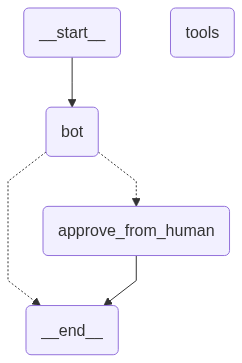

In [11]:
display(Image(app.get_graph().draw_mermaid_png()))

In [12]:
# A thread_id is mandatory so the graph knows which state to resume
config = {"configurable": {"thread_id": "thread_1"}}

# Step 1: Initial user prompt
initial_input = {"messages": [HumanMessage(content="What is the weather in Peshawar?")]}

print("--- INITIAL RUN ---")
for event in app.stream(initial_input, config):
    print(event)


# The graph is now paused. You can inspect the state to confirm:
    state = app.get_state(config)
    print("\nNext node to run:", state.next) # Will print ('approve_from_human',)

# Step 2: Resume with human approval
# We pass the human's response directly into Command(resume=...)
    print("\n--- RESUMING RUN ---")



    for event in app.stream(Command(resume="yes"), config):
        print(event)

--- INITIAL RUN ---
{'bot': {'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks current weather in Peshawar. Need to call getweather_api.', 'tool_calls': [{'id': 'fc_d6febb47-8c04-4715-b7d8-4818782e5e65', 'function': {'arguments': '{"city":"Peshawar"}', 'name': 'getweather_api'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 265, 'total_tokens': 312, 'completion_time': 0.10259183, 'completion_tokens_details': {'reasoning_tokens': 17}, 'prompt_time': 0.060655251, 'prompt_tokens_details': None, 'queue_time': 0.396513155, 'total_time': 0.163247081}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_84bf0227ec', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a05db8-9d86-7b80-ba9a-1607a62a5728-0', tool_calls=[{'name': 'getweather_api', 'args': {'city': 'Peshawar'}, 'id': 'fc_d6febb47-8c04-4715-b7d8-4818782e5e65', 'type'

In [13]:
# A thread_id is mandatory so the graph knows which state to resume
config = {"configurable": {"thread_id": "thread_1"}}

# Step 1: Initial user prompt
initial_input = {"messages": [HumanMessage(content="What is the weather in Peshawar?")]}

print("--- INITIAL RUN ---")
for event in app.stream(initial_input, config):
    print(event)


# The graph is now paused. You can inspect the state to confirm:
    state = app.get_state(config)
    print("\nNext node to run:", state.next) # Will print ('approve_from_human',)

# Step 2: Resume with human approval
# We pass the human's response directly into Command(resume=...)
    print("\n--- RESUMING RUN ---")



    for event in app.stream(Command(resume="no"), config):
        print(event)

--- INITIAL RUN ---
{'bot': {'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks again. Possibly they want updated weather. We can fetch again.', 'tool_calls': [{'id': 'fc_b6e29639-ed19-4d21-b584-c97b98baad74', 'function': {'arguments': '{"city":"Peshawar"}', 'name': 'getweather_api'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 390, 'total_tokens': 428, 'completion_time': 0.078997776, 'completion_tokens_details': {'reasoning_tokens': 17}, 'prompt_time': 0.12198405, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.24617439, 'total_time': 0.200981826}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e1a78f200e', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a05db8-ac1f-7142-ab01-35d7c684c031-0', tool_calls=[{'name': 'getweather_api', 'args': {'city': 'Peshawar'}, 'id': 'fc_b6e29639-ed19-4d21-

In [14]:
'''import uuid
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langgraph.types import Command

def print_event(event: dict):
    """Helper function to cleanly format and log state updates."""
    for node_name, state_update in event.items():
        print(f"\n⚡ [Node Executed]: {node_name}")
        
        messages = state_update.get("messages", [])
        if not isinstance(messages, list):
            messages = [messages]
            
        for msg in messages:
            if isinstance(msg, AIMessage):
                if msg.tool_calls:
                    for tc in msg.tool_calls:
                        print(f"  🤖 LLM requested tool: {tc['name']} with args {tc['args']}")
                else:
                    print(f"  🤖 LLM Response: {msg.content}")
            elif isinstance(msg, ToolMessage):
                print(f"  🔧 Tool [{msg.name}] Output: {msg.content}")
            elif isinstance(msg, HumanMessage):
                print(f"  👤 User: {msg.content}")


def run_interactive_chat(app):
    session_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": session_id}}
    
    print("=" * 60)
    print("Agent initialized. Type 'quit' or 'exit' to stop.")
    print("=" * 60)

    while True:
        user_input = input("\nUser: ").strip()
        if user_input.lower() in ["quit", "exit"]:
            print("Session ended.")
            break
        if not user_input:
            continue

        # 1. Stream the initial user request
        stream_input = {"messages": [HumanMessage(content=user_input)]}
        
        while True:
            for event in app.stream(stream_input, config, stream_mode="updates"):
                print_event(event)

            # 2. Check if the graph reached an interrupt / paused state
            state = app.get_state(config)
            
            if not state.next:
                # Execution finished (reached END)
                break
                
            # If paused on an interrupt node (e.g., 'approve_from_human')
            if "approve_from_human" in state.next:
                # Extract the message passed into the interrupt() call
                interrupt_data = state.tasks[0].interrupts[0].value if state.tasks and state.tasks[0].interrupts else "Approval required."
                
                print(f"\n⚠️  [HUMAN APPROVAL REQUIRED]: {interrupt_data}")
                human_choice = input("👉 Approve execution? (yes/no): ").strip().lower()

                # 3. Resume the graph with the human's response
                stream_input = Command(resume=human_choice)


# Run the live interactive loop
if __name__ == "__main__":
    run_interactive_chat(app)'''

'import uuid\nfrom langchain_core.messages import HumanMessage, AIMessage, ToolMessage\nfrom langgraph.types import Command\n\ndef print_event(event: dict):\n    """Helper function to cleanly format and log state updates."""\n    for node_name, state_update in event.items():\n        print(f"\n⚡ [Node Executed]: {node_name}")\n\n        messages = state_update.get("messages", [])\n        if not isinstance(messages, list):\n            messages = [messages]\n\n        for msg in messages:\n            if isinstance(msg, AIMessage):\n                if msg.tool_calls:\n                    for tc in msg.tool_calls:\n                        print(f"  🤖 LLM requested tool: {tc[\'name\']} with args {tc[\'args\']}")\n                else:\n                    print(f"  🤖 LLM Response: {msg.content}")\n            elif isinstance(msg, ToolMessage):\n                print(f"  🔧 Tool [{msg.name}] Output: {msg.content}")\n            elif isinstance(msg, HumanMessage):\n                print(f" 